In [18]:
import pandas as pd
import matplotlib.pyplot as plt


class GraficosAmazon:
    """
    ==========================================================
                CLASE PARA EL ANÁLISIS DE PRODUCTOS AMAZON
    ==========================================================

    Esta clase recibe el archivo CSV generado por el scraper
    y prepara la información para la creación de distintos
    gráficos estadísticos.

    Los gráficos permiten analizar:

    - Distribución de precios.
    - Rangos de precios.
    - Relación entre precio y valoración.
    - Distribución de calificaciones.
    - Valores atípicos.

    ==========================================================
    """

    def __init__(self, archivo_csv):
        """
        Constructor de la clase.

        Parámetros
        ----------
        archivo_csv : str
            Ruta del archivo CSV generado por el scraper.

        Al crear el objeto:

        1. Se carga el archivo CSV.
        2. Se limpian los precios.
        3. Se limpian las calificaciones.
        """

        self.archivo = archivo_csv

        # Leer el archivo CSV
        self.df = pd.read_csv(self.archivo)

        # Preparar los datos
        self.__limpiar_precios()
        self.__limpiar_estrellas()

    ####################################################################
    #               MÉTODOS PRIVADOS DE LIMPIEZA
    ####################################################################

    def __limpiar_precios(self):
        """
        Convierte la columna 'precio' en valores numéricos.

        Elimina símbolos de moneda como:
        "PEN 148.40"

        pasa a

        29.99

        Los productos sin precio quedan como NaN.
        """

        if "precio" not in self.df.columns:
            return

        self.df["precio"] = (
            self.df["precio"]
            .astype(str)
            .str.extract(r"([0-9]+\.?[0-9]*)")[0]
        )

        self.df["precio"] = pd.to_numeric(
            self.df["precio"],
            errors="coerce"
        )

    def __limpiar_estrellas(self):
        """
        Convierte las calificaciones en números.

        Ejemplos

        "4.8 out of 5 stars"

        pasa a

        4.8
        """

        if "estrellas" not in self.df.columns:
            return

        self.df["estrellas"] = (
            self.df["estrellas"]
            .astype(str)
            .str.extract(r"([0-9]+\.[0-9]+)")
        )

        self.df["estrellas"] = pd.to_numeric(
            self.df["estrellas"],
            errors="coerce"
        )

    ####################################################################
    #               INFORMACIÓN GENERAL
    ####################################################################

    def informacion(self):
        """
        Muestra información general del conjunto de datos.

        Esta función sirve para comprobar que los datos
        fueron cargados correctamente antes de generar
        las gráficas.
        """

        print("\n==============================")
        print("INFORMACIÓN DEL DATASET")
        print("==============================")

        print(f"Número de productos: {len(self.df)}")
        print(f"Columnas: {list(self.df.columns)}")

        print("\nPrimeros registros\n")
        print(self.df.head())

        print("\nValores faltantes\n")
        print(self.df.isnull().sum())

        print("\nResumen estadístico\n")
        print(self.df.describe())

    ####################################################################
    #   LOS MÉTODOS DE LOS GRÁFICOS SE AÑADIRÁN EN LOS SIGUIENTES
    #   BLOQUES.
    ####################################################################
        ####################################################################
    #                   GRÁFICO 1
    ####################################################################

    def histograma_precios(self):
        """
        Histograma de precios.

        Representa la distribución de los precios de los productos
        obtenidos durante el scraping.

        Permite identificar:

        - El rango de precios más frecuente.
        - Si predominan productos baratos o caros.
        - La dispersión de los precios.
        """

        precios = self.df["precio"].dropna()

        plt.figure(figsize=(10,6))

        plt.hist(precios, bins=15)

        plt.title("Distribución de precios de parlantes Bluetooth")

        plt.xlabel("Precio (USD)")
        plt.ylabel("Cantidad de productos")

        plt.grid(True)

        plt.show()

    ####################################################################
    #                   GRÁFICO 2
    ####################################################################

    def barras_rangos_precios(self):
        """
        Gráfico de barras por rangos de precios.

        Los productos se agrupan en cuatro categorías:

        Menos de 20 dólares
        Entre 20 y 50 dólares
        Entre 50 y 100 dólares
        Más de 100 dólares

        Este gráfico permite conocer cuál es el rango de precio
        predominante dentro del conjunto de datos.
        """

        precios = self.df["precio"].dropna()

        rangos = pd.cut(
            precios,
            bins=[0,20,50,100,float("inf")],
            labels=[
                "< $20",
                "$20 - $50",
                "$50 - $100",
                "> $100"
            ]
        )

        conteo = rangos.value_counts().sort_index()

        plt.figure(figsize=(8,6))

        plt.bar(conteo.index.astype(str), conteo.values)

        plt.title("Cantidad de productos por rango de precio")

        plt.xlabel("Rango de precios")
        plt.ylabel("Número de productos")

        plt.grid(axis="y")

        plt.show()

    ####################################################################
    #                   GRÁFICO 3
    ####################################################################

    def boxplot_precios(self):
        """
        Diagrama de cajas (Boxplot).

        Este gráfico resume estadísticamente los precios
        mostrando:

        - Precio mínimo.
        - Primer cuartil.
        - Mediana.
        - Tercer cuartil.
        - Precio máximo.
        - Valores atípicos.

        Es uno de los gráficos más utilizados para detectar
        productos con precios excesivamente altos o bajos.
        """

        precios = self.df["precio"].dropna()

        plt.figure(figsize=(8,6))

        plt.boxplot(precios)

        plt.title("Boxplot de precios")

        plt.ylabel("Precio (USD)")

        plt.grid(True)

        plt.show()    
    ####################################################################
    #                   GRÁFICO 4
    ####################################################################

    def dispersion_precio_estrellas(self):
        """
        Gráfico de dispersión (Scatter Plot).

        Cada punto representa un producto.

        Eje X:
            Precio del producto.

        Eje Y:
            Calificación del producto.

        Este gráfico permite observar si existe alguna relación
        entre el precio de un parlante y la valoración otorgada
        por los compradores.
        """

        datos = self.df.dropna(subset=["precio", "estrellas"])

        plt.figure(figsize=(10,6))

        plt.scatter(
            datos["precio"],
            datos["estrellas"],
            alpha=0.7
        )

        plt.title("Relación entre precio y calificación")

        plt.xlabel("Precio (USD)")
        plt.ylabel("Calificación")

        plt.grid(True)

        plt.show()

    ####################################################################
    #                   GRÁFICO 5
    ####################################################################

    def barras_estrellas(self):
        """
        Gráfico de barras de las calificaciones.

        Muestra cuántos productos poseen cada nivel de valoración.

        Permite identificar si la mayoría de los parlantes
        presentan buenas o malas opiniones por parte de los usuarios.
        """

        estrellas = self.df["estrellas"].dropna()

        conteo = estrellas.value_counts().sort_index()

        plt.figure(figsize=(10,6))

        plt.bar(
            conteo.index.astype(str),
            conteo.values
        )

        plt.title("Distribución de calificaciones")

        plt.xlabel("Estrellas")

        plt.ylabel("Cantidad de productos")

        plt.grid(axis="y")

        plt.show()

    ####################################################################
    #                   GRÁFICO 6
    ####################################################################

    def productos_mas_caros(self):
        """
        Gráfico de barras de los diez productos más caros.

        Ordena los productos según su precio y muestra
        únicamente los diez con mayor valor.

        Resulta útil para identificar los artículos premium
        presentes dentro del conjunto de datos.
        """

        datos = (
            self.df
            .dropna(subset=["precio"])
            .sort_values("precio", ascending=False)
            .head(10)
        )

        etiquetas = [
            f"Producto {i+1}"
            for i in range(len(datos))
        ]

        plt.figure(figsize=(12,6))

        plt.bar(
            etiquetas,
            datos["precio"]
        )

        plt.title("Los 10 productos más caros")

        plt.xlabel("Productos")

        plt.ylabel("Precio (USD)")

        plt.xticks(rotation=45)

        plt.grid(axis="y")

        plt.show()

In [ ]:
graficos = GraficosAmazon("parlantes_bluetooth_amazon.csv")
graficos.informacion()


INFORMACIÓN DEL DATASET
Número de productos: 100
Columnas: ['id', 'precio', 'estrellas', 'link']

Primeros registros

           id  precio  estrellas                                        link
0  B01MTB55WH  148.40        4.5  https://www.amazon.com/-/es/dp/B01MTB55WH/
1  B0GS99FG9P  102.52        4.5  https://www.amazon.com/-/es/dp/B0GS99FG9P/
2  B0GHSL9FPR  153.80        4.5  https://www.amazon.com/-/es/dp/B0GHSL9FPR/
3  B08X4YMTPM     NaN        4.8  https://www.amazon.com/-/es/dp/B08X4YMTPM/
4  B0CX1FRR27   68.34        4.6  https://www.amazon.com/-/es/dp/B0CX1FRR27/

Valores faltantes

id            0
precio       15
estrellas     0
link          0
dtype: int64

Resumen estadístico

           precio   estrellas
count   85.000000  100.000000
mean   191.309647    4.486000
std    174.847993    0.185875
min     34.150000    4.000000
25%     71.410000    4.400000
50%    123.040000    4.500000
75%    239.270000    4.600000
max    854.650000    5.000000


## Histograma 
El histograma de precios permite visualizar la distribución de los precios de los parlantes Bluetooth obtenidos durante el proceso de scraping. Cada barra representa la cantidad de productos cuyo precio se encuentra dentro de un determinado intervalo.

Este gráfico es útil para identificar el rango de precios más frecuente, detectar si predominan productos económicos o de mayor costo y observar la dispersión general de los precios. Además, permite reconocer si existen concentraciones de productos en determinados niveles de precio o si la distribución presenta una mayor variabilidad.

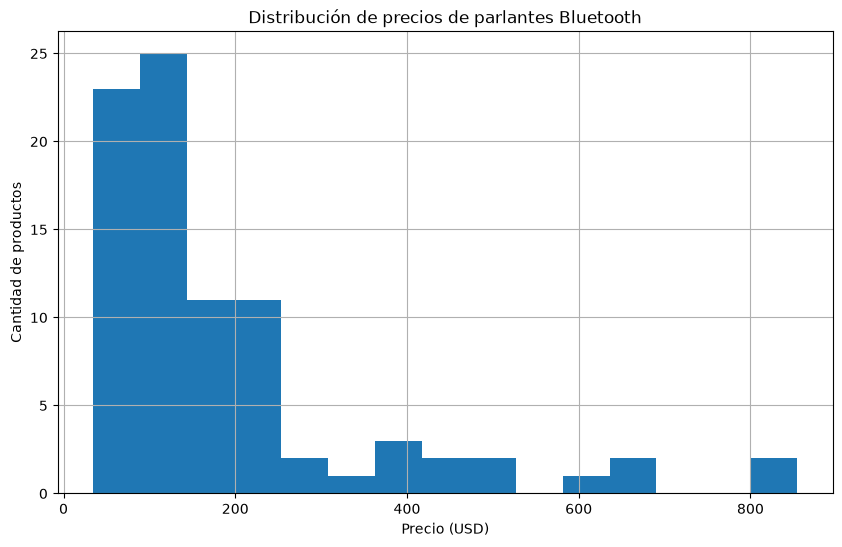

In [25]:
graficos.histograma_precios()

## Gráfico de barras por rangos de precios


El gráfico de barras clasifica los productos en distintos rangos de precios (menores a $20, entre $20 y $50, entre $50 y $100 y mayores a $100), mostrando la cantidad de productos que pertenecen a cada categoría.

Este tipo de representación facilita comparar rápidamente la oferta de productos según su nivel de precio, permitiendo identificar cuál es el segmento de mercado con mayor presencia dentro de los resultados obtenidos. También resulta útil para analizar la distribución comercial de los productos disponibles en Amazon.

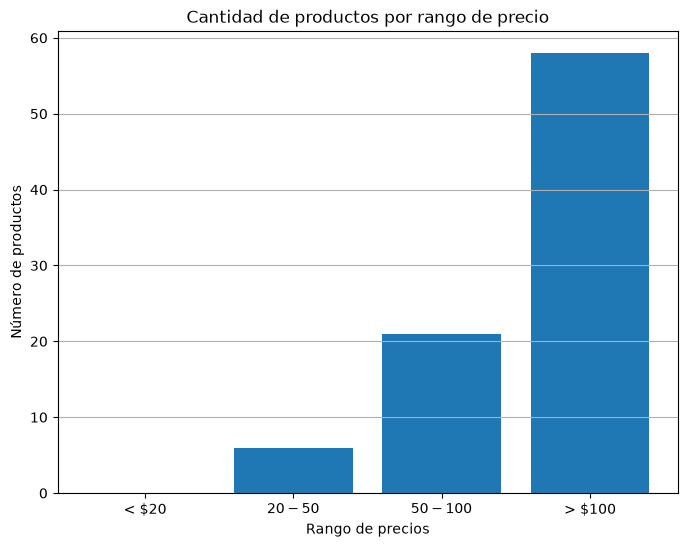

In [26]:
graficos.barras_rangos_precios()

## Boxplot (Diagrama de cajas)


El diagrama de cajas, conocido como Boxplot, resume estadísticamente la distribución de los precios mediante cinco valores fundamentales: el precio mínimo, el primer cuartil, la mediana, el tercer cuartil y el precio máximo.

Además, permite identificar valores atípicos (outliers), es decir, productos cuyos precios son considerablemente superiores o inferiores al resto de los datos. Este gráfico resulta especialmente útil para analizar la dispersión de los precios y detectar la existencia de productos premium o de ofertas poco comunes dentro del conjunto de datos.

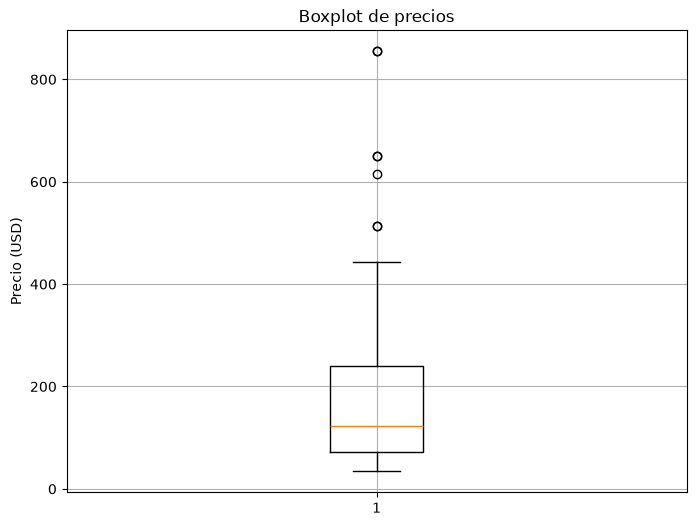

In [27]:
graficos.boxplot_precios()

## Gráfico de dispersión (Precio vs. Calificación)
El gráfico de dispersión representa la relación existente entre el precio de cada producto y su calificación promedio otorgada por los usuarios de Amazon. Cada punto corresponde a un producto individual, ubicándose en el eje horizontal según su precio y en el eje vertical según su valoración.

Este gráfico permite analizar si existe alguna relación entre ambas variables, por ejemplo, si los productos más costosos suelen recibir mejores calificaciones o si los productos económicos presentan niveles de satisfacción similares a los de mayor precio. Asimismo, facilita identificar productos con una excelente valoración a un precio reducido o productos costosos con calificaciones relativamente bajas.

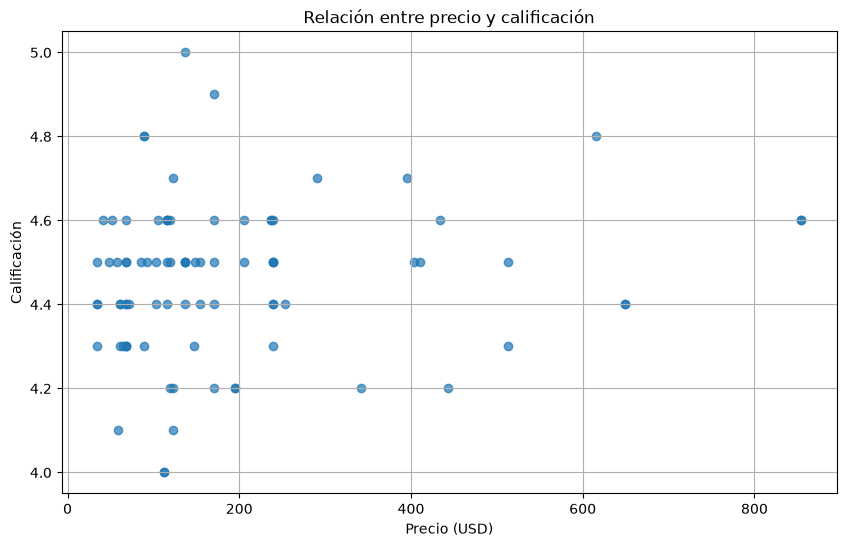

In [28]:
graficos.dispersion_precio_estrellas()

## Gráfico de los 10 productos más caros
Este gráfico presenta los diez productos con mayor precio dentro del conjunto de datos obtenido mediante el scraping. Cada barra representa uno de estos productos y su altura corresponde a su precio.

Su principal objetivo es identificar los productos pertenecientes al segmento de mayor costo del mercado, permitiendo realizar comparaciones entre ellos y analizar la diferencia existente respecto al resto de la oferta. Asimismo, facilita detectar la presencia de productos de gama alta o modelos especializados que presentan un precio significativamente superior al promedio.

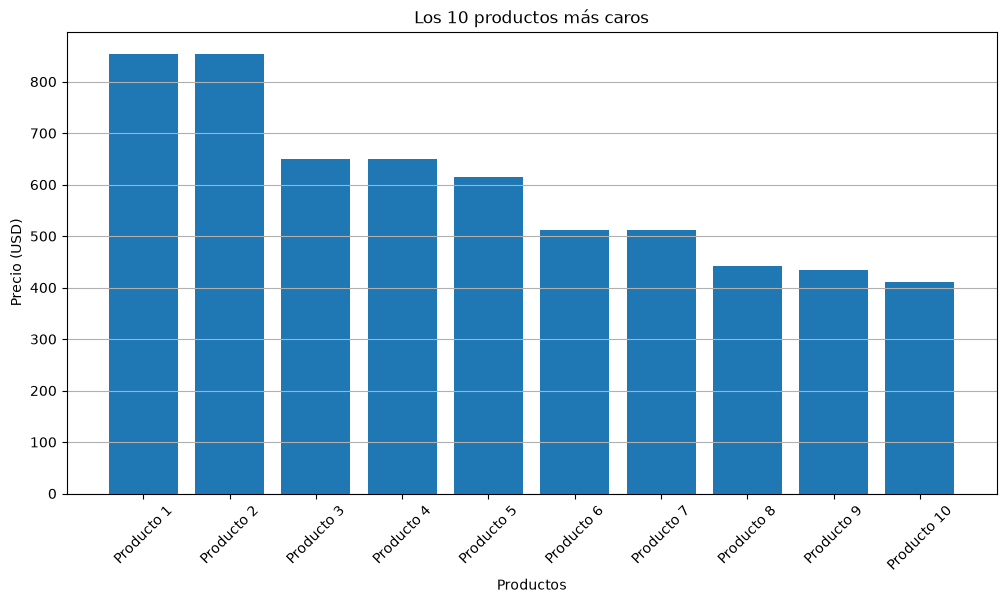

In [24]:
graficos.productos_mas_caros()